In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold, cross_val_predict
import lightgbm as lgb
import xgboost as xgb
import numpy as np
import optuna
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

warnings.simplefilter(action='ignore', category=FutureWarning)

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [4]:
train = pd.read_csv('/kaggle/input/can-you-predict-a-smokers-status-with-bio-signals-cmuafrica/train.csv')
test  = pd.read_csv('/kaggle/input/can-you-predict-a-smokers-status-with-bio-signals-cmuafrica/test.csv')
sample = pd.read_csv('/kaggle/input/can-you-predict-a-smokers-status-with-bio-signals-cmuafrica/sample_submission.csv')

In [5]:
test.head()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
0,15000,40.0,175.0,80.0,95.0,1.0,0.8,1.0,1.0,118.0,...,203.0,39.0,118.0,14.8,1.0,0.8,39.0,64.0,48.0,0.0
1,15001,60.0,165.0,55.0,79.0,0.9,1.2,1.0,1.0,130.0,...,82.0,52.0,121.0,15.0,1.0,0.9,21.0,21.0,17.0,0.0
2,15002,45.0,160.0,60.0,73.2,0.9,0.9,1.0,1.0,110.0,...,77.0,64.0,129.0,9.2,1.0,0.7,16.0,10.0,11.0,0.0
3,15003,55.0,165.0,55.0,79.0,0.9,0.8,1.0,1.0,122.0,...,113.0,54.0,105.0,15.4,1.0,0.9,25.0,25.0,27.0,0.0
4,15004,35.0,180.0,85.0,90.0,0.6,0.6,1.0,1.0,116.0,...,274.0,45.0,137.0,16.3,1.0,1.1,27.0,29.0,47.0,0.0


In [6]:
# train.head()
train.info()
# train.describe()
# train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   15000 non-null  int64  
 1   age                  15000 non-null  float64
 2   height(cm)           15000 non-null  float64
 3   weight(kg)           15000 non-null  float64
 4   waist(cm)            15000 non-null  float64
 5   eyesight(left)       15000 non-null  float64
 6   eyesight(right)      15000 non-null  float64
 7   hearing(left)        15000 non-null  float64
 8   hearing(right)       15000 non-null  float64
 9   systolic             15000 non-null  float64
 10  relaxation           15000 non-null  float64
 11  fasting blood sugar  15000 non-null  float64
 12  Cholesterol          15000 non-null  float64
 13  triglyceride         15000 non-null  float64
 14  HDL                  15000 non-null  float64
 15  LDL                  15000 non-null 

smoking
0.0    9450
1.0    5550
Name: count, dtype: int64


<Axes: xlabel='smoking', ylabel='count'>

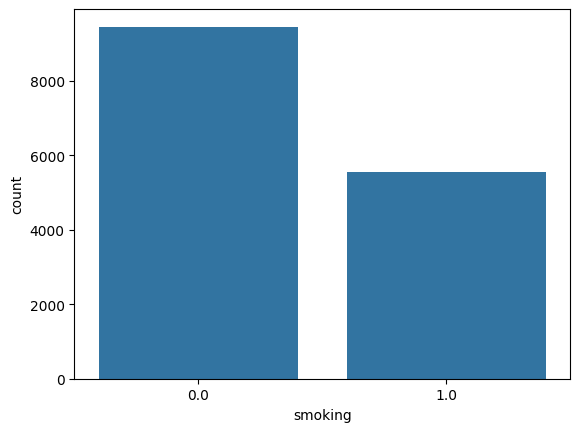

In [7]:
print(train['smoking'].value_counts())
sns.countplot(data=train, x='smoking')


In [8]:
corr = train.drop('id', axis=1).corr()['smoking'].sort_values(ascending=False)
# corr.drop('smoking').plot(kind='barh', color='skyblue')
abs_corr = corr.abs().sort_values(ascending=False).drop('smoking')
abs_corr

# abs_corr.plot(kind='barh', color='salmon')

hemoglobin             0.507871
height(cm)             0.485483
weight(kg)             0.389009
Gtp                    0.366896
serum creatinine       0.354947
triglyceride           0.338520
waist(cm)              0.294235
HDL                    0.293898
ALT                    0.240986
age                    0.210268
relaxation             0.153253
eyesight(right)        0.136476
eyesight(left)         0.134070
dental caries          0.133253
systolic               0.110415
fasting blood sugar    0.103204
AST                    0.096044
Cholesterol            0.048334
LDL                    0.035371
hearing(left)          0.021617
Urine protein          0.014817
hearing(right)         0.013793
Name: smoking, dtype: float64

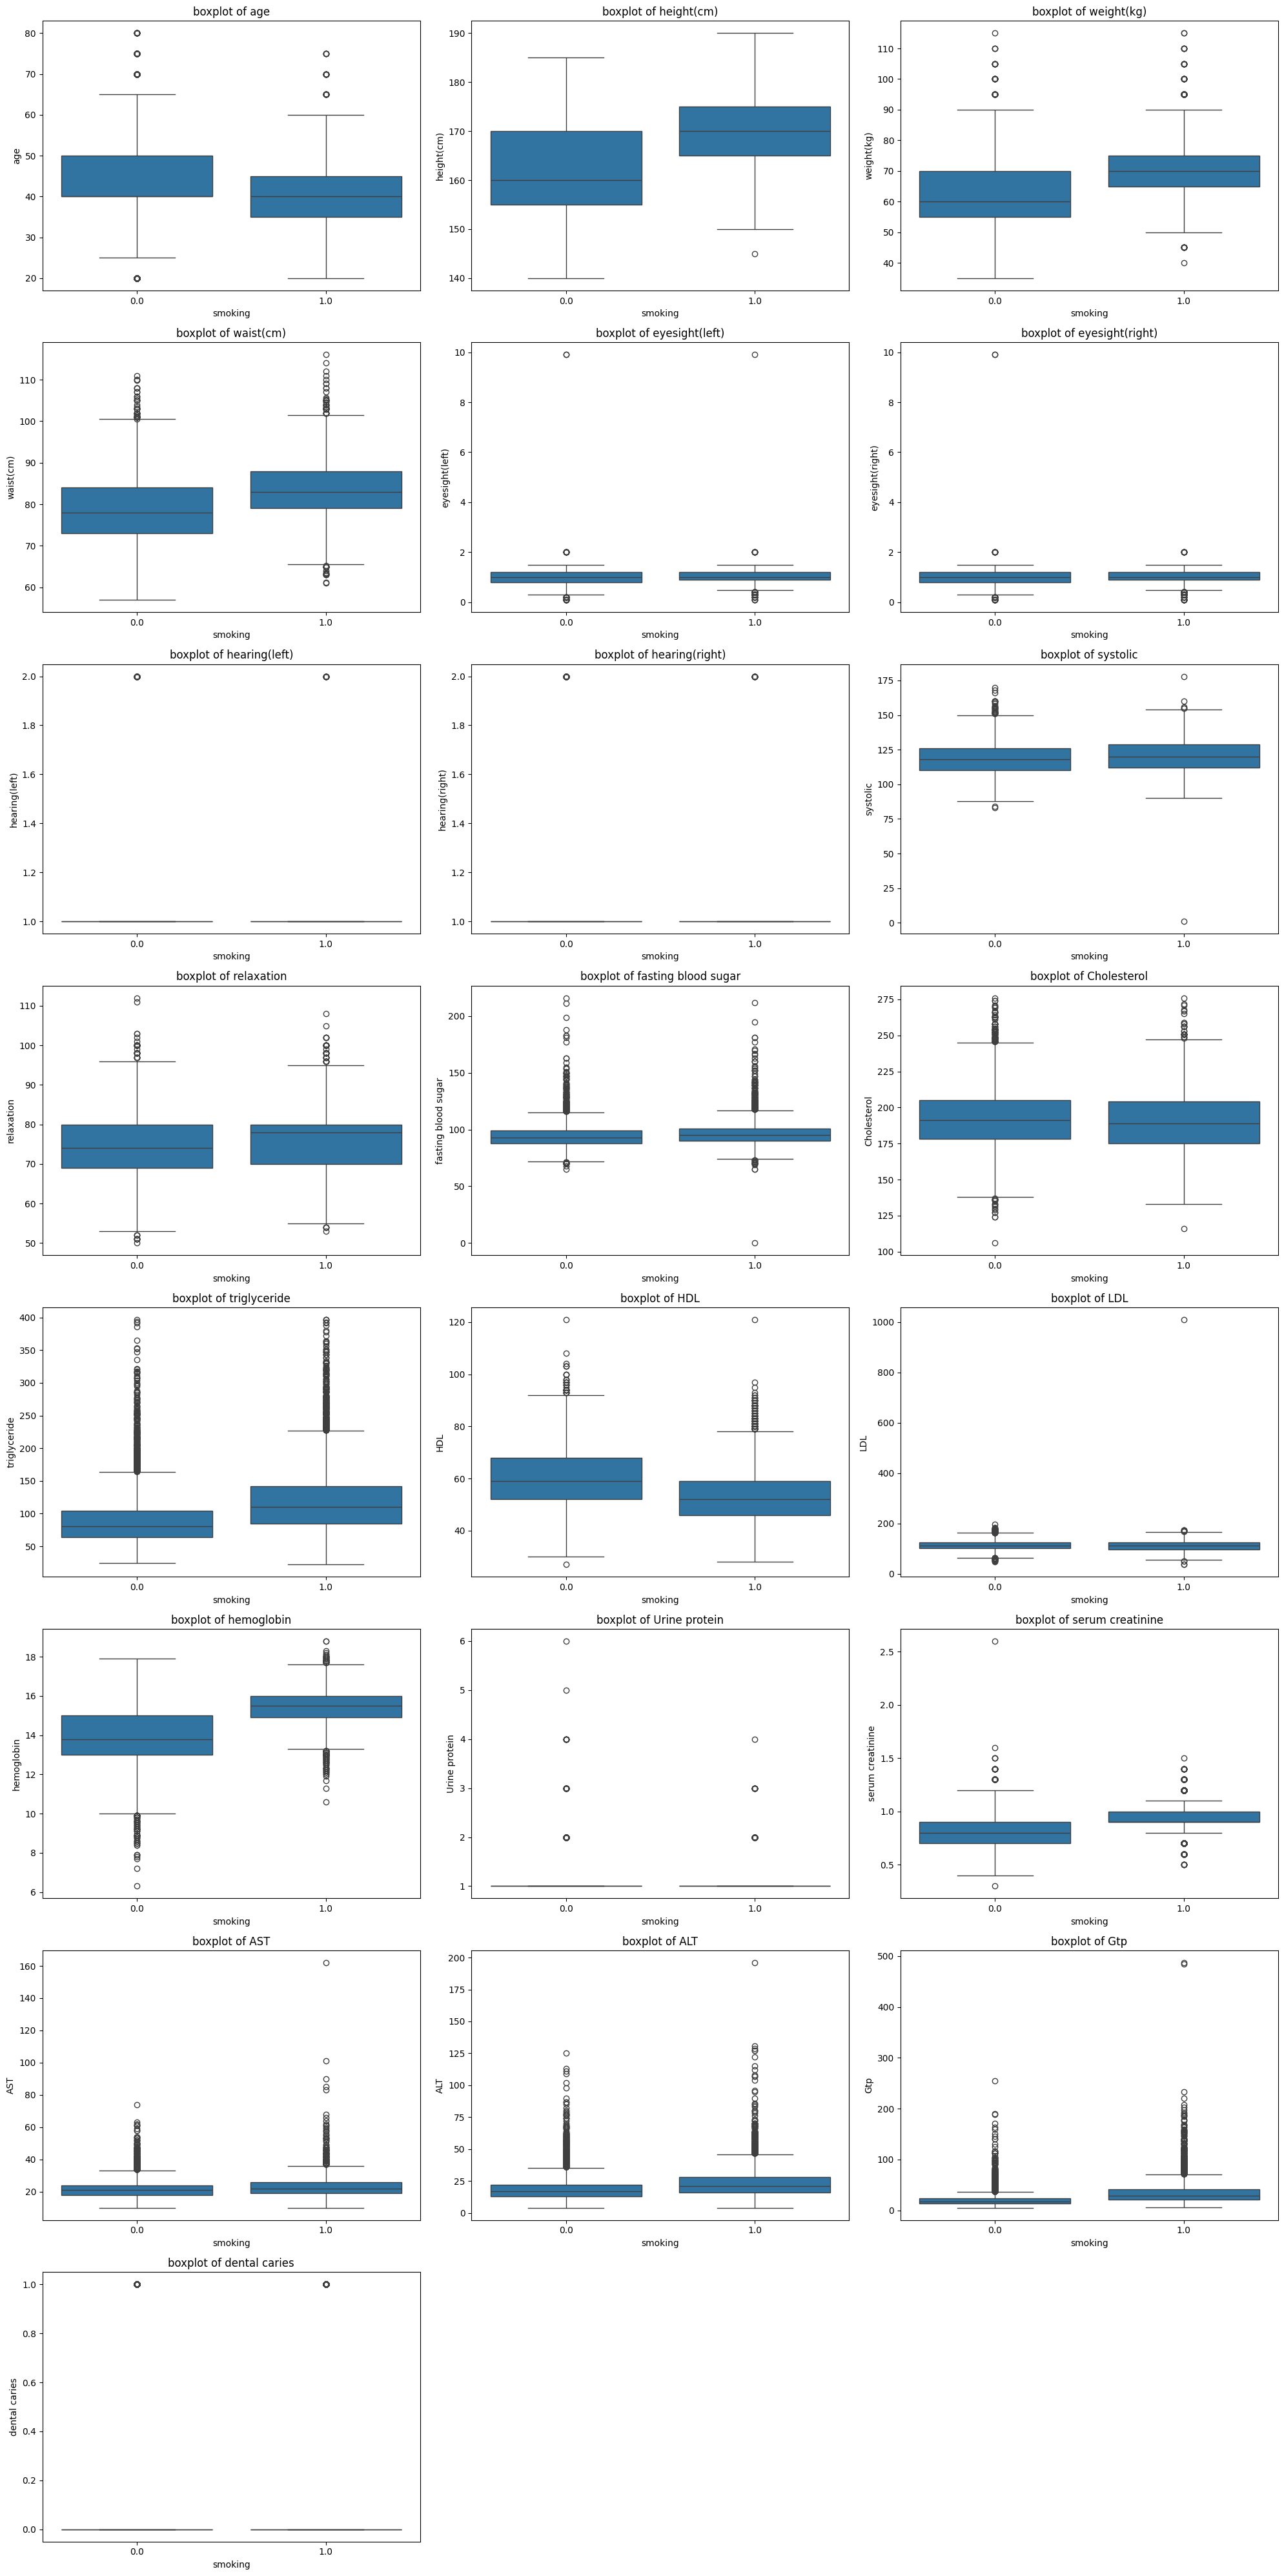

In [9]:
numeric_cols = [col for col in train.columns if col not in ['id', 'smoking']]

plt.figure(figsize=(20, 40))
for idx, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols)//3 + 1, 3, idx + 1)
    sns.boxplot(data=train, x='smoking', y=col)
    plt.title(f'boxplot of {col}')
plt.tight_layout()
plt.show()

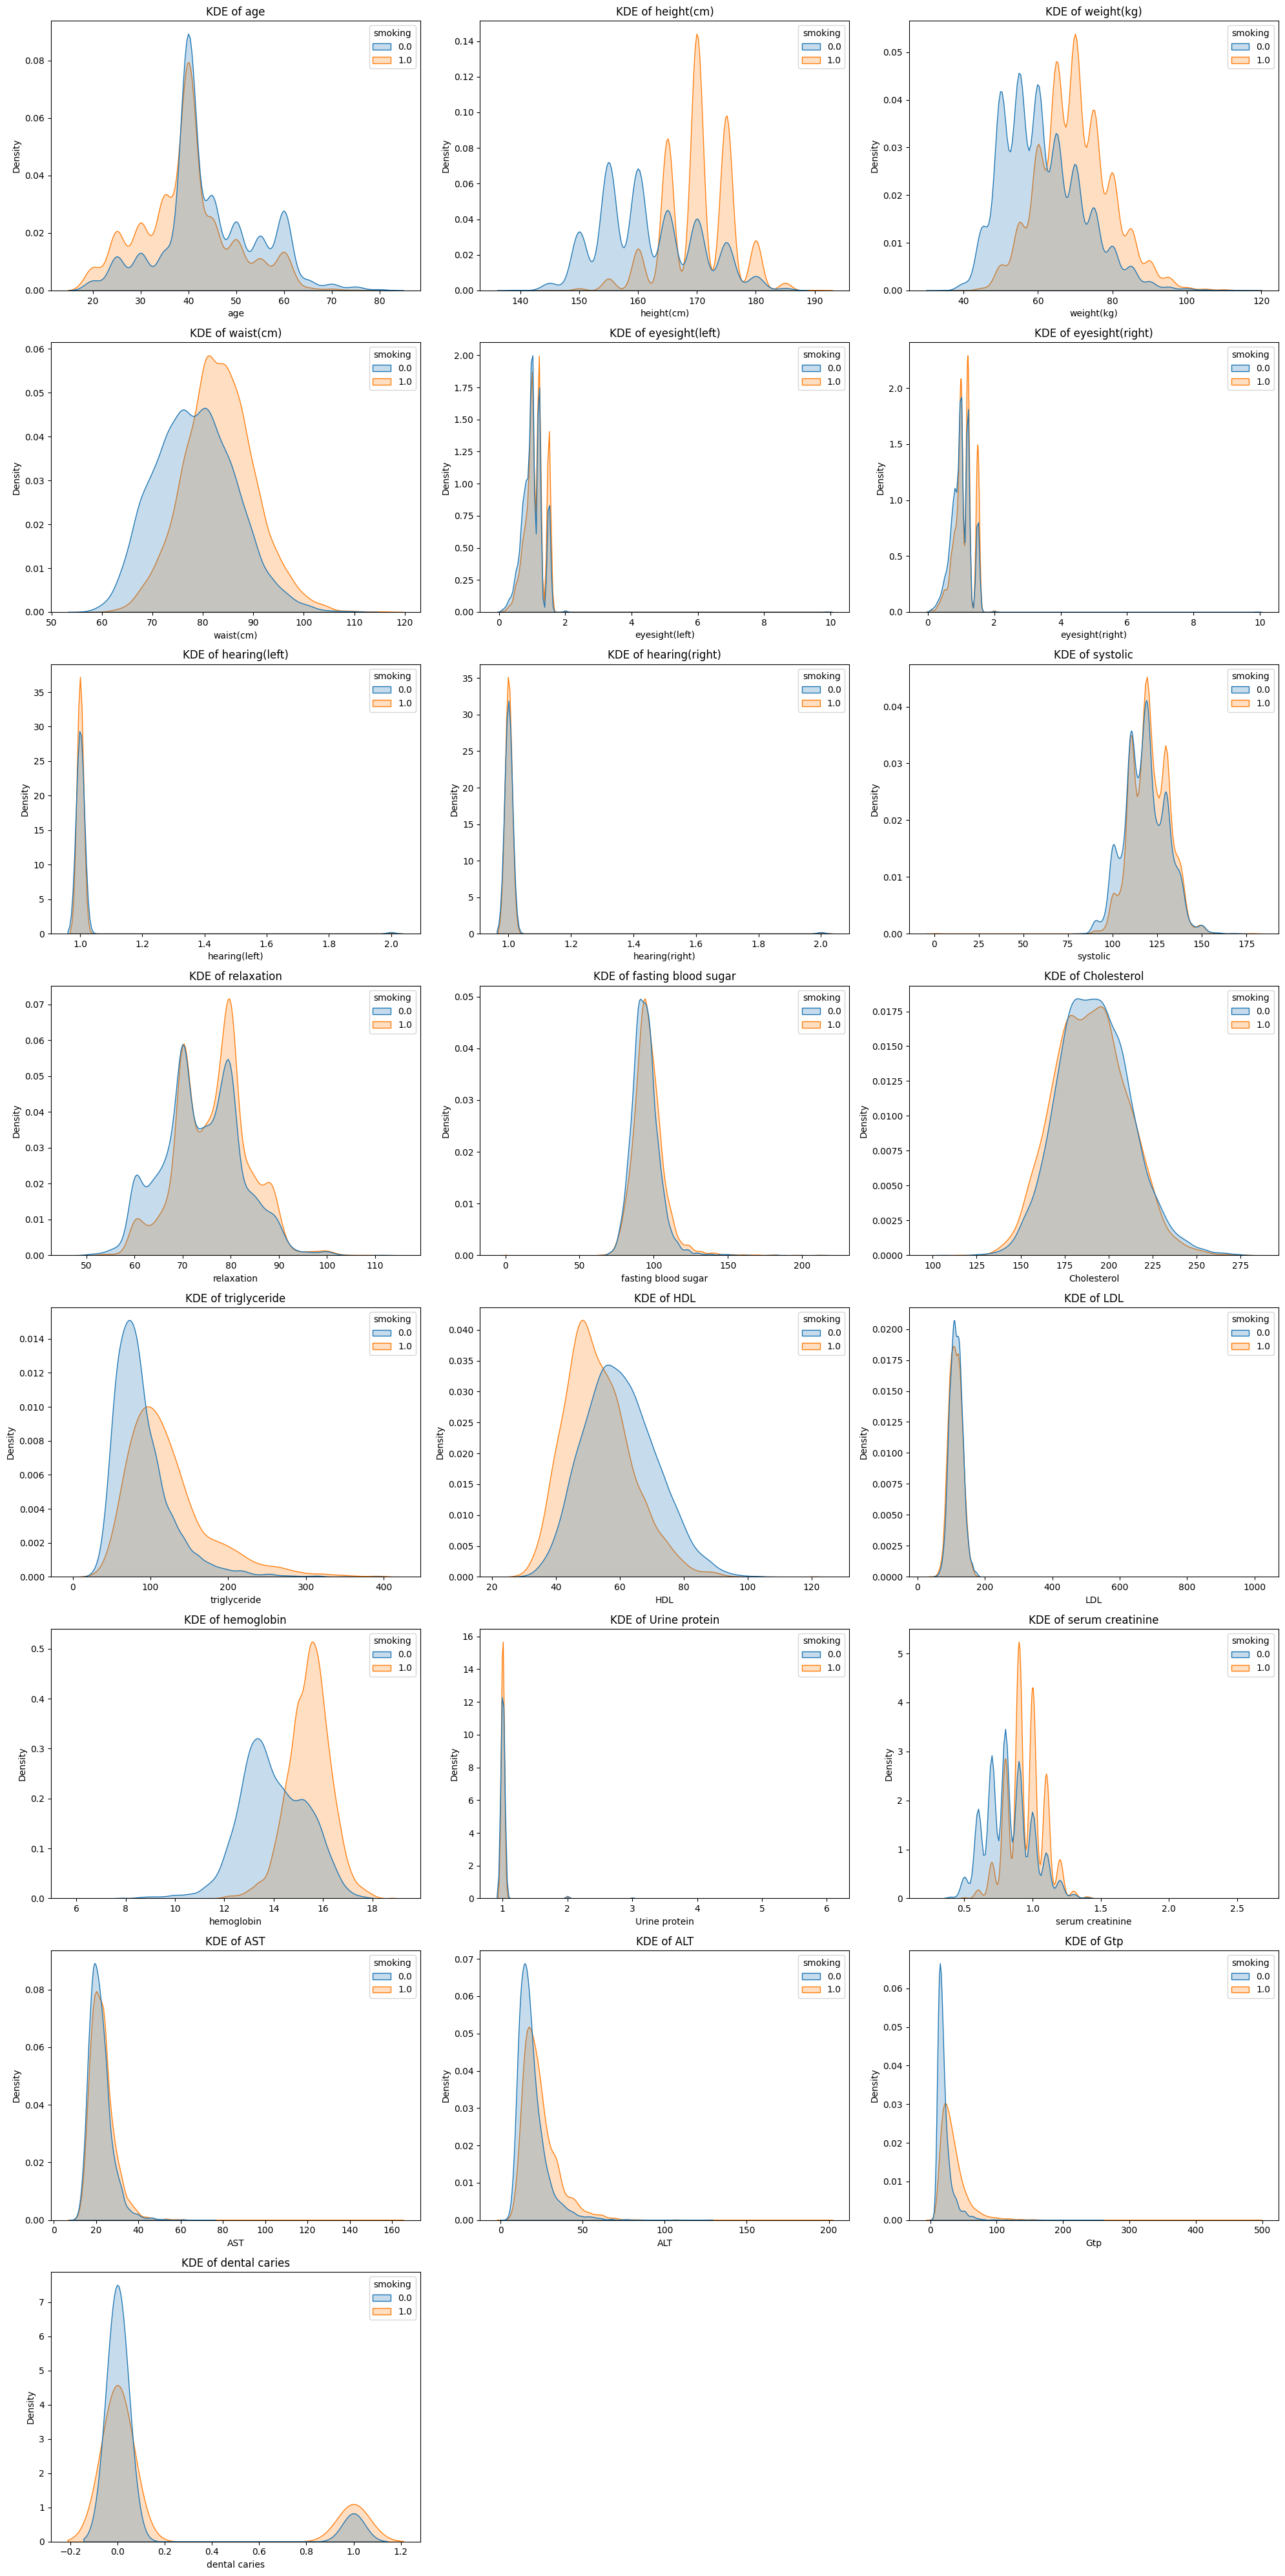

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(20, 40))
for idx, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, idx + 1)
    sns.kdeplot(data=train, x=col, hue='smoking', fill=True, common_norm=False)
    plt.title(f'KDE of {col}')
plt.tight_layout()
plt.show()

plt.savefig('kde.png')

In [11]:
train.columns

Index(['id', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)',
       'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic',
       'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride',
       'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST',
       'ALT', 'Gtp', 'dental caries', 'smoking'],
      dtype='object')

In [13]:
def feature_engineering(df):
    df = df.copy()
    
    df['hgb_gtp'] = df['hemoglobin'] * df['Gtp']
    df['hgb_height_ratio'] = df['hemoglobin'] / (df['height(cm)'] + 1e-9)
    df['liver_sum'] = df['AST'] + df['ALT'] + df['Gtp'] 
    
    df['bmi'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
    df['waist_height_ratio'] = df['waist(cm)'] / (df['height(cm)'] + 1e-9)
    
    df['log_Gtp'] = np.log1p(df['Gtp'])
    df['log_triglyceride'] = np.log1p(df['triglyceride'])
    
    noise_cols = ['hearing(left)', 'hearing(right)', 'Urine protein']
    df = df.drop(columns=noise_cols)

    return df

train_new = feature_engineering(train)
test_new = feature_engineering(test)

y = train_new['smoking']

X = train_new.drop(['id', 'smoking'], axis=1)

X_test = test_new.drop(['id'], axis=1)

In [15]:
def feature_engineering(df):
    df = df.copy()
    df['hgb_gtp'] = df['hemoglobin'] * df['Gtp']
    df['hgb_height_ratio'] = df['hemoglobin'] / (df['height(cm)'] + 1e-9)
    df['bmi'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
    df['waist_height_ratio'] = df['waist(cm)'] / (df['height(cm)'] + 1e-9)
    df['log_Gtp'] = np.log1p(df['Gtp'])
    df['log_triglyceride'] = np.log1p(df['triglyceride'])
    df['ast_alt_ratio'] = df['AST'] / (df['ALT'] + 1e-9)
    df['tg_hdl_ratio'] = df['triglyceride'] / (df['HDL'] + 1e-9)
    df['creat_hemo_ratio'] = df['serum creatinine'] / (df['hemoglobin'] + 1e-9)
    df['age_hgb'] = df['age'] * df['hemoglobin']
    noise_cols = [
        'hearing(left)', 'hearing(right)', 'Urine protein', 
        'eyesight(left)', 'eyesight(right)', 'systolic'
    ]
    df = df.drop(columns=noise_cols)
    return df

train_new = feature_engineering(train)
test_new = feature_engineering(test)

y = train_new['smoking']
X = train_new.drop(['id', 'smoking'], axis=1)
X_test = test_new.drop(['id'], axis=1)

In [19]:


def xgb_objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
       'scale_pos_weight': 1.7,
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBClassifier(**param)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()

study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=30) 

print(f"Best Optuna Score: {study.best_value:.5f}")
print(f"Best Params: {study.best_params}")

best_xgb_model = xgb.XGBClassifier(**study.best_params, scale_pos_weight=1.7, random_state=42)
best_xgb_model.fit(X, y)

[I 2026-01-11 19:07:14,802] A new study created in memory with name: no-name-e0fceb83-8c0e-4b96-91df-67fd722f5ad0
[I 2026-01-11 19:07:37,389] Trial 0 finished with value: 0.8864221364221365 and parameters: {'n_estimators': 1769, 'max_depth': 7, 'learning_rate': 0.02171340414339075, 'subsample': 0.9766398489815713, 'colsample_bytree': 0.5368450330998107, 'min_child_weight': 1}. Best is trial 0 with value: 0.8864221364221365.
[I 2026-01-11 19:07:43,630] Trial 1 finished with value: 0.890079079079079 and parameters: {'n_estimators': 1342, 'max_depth': 3, 'learning_rate': 0.03522630532679308, 'subsample': 0.8933192799253605, 'colsample_bytree': 0.624509204492984, 'min_child_weight': 7}. Best is trial 1 with value: 0.890079079079079.
[I 2026-01-11 19:08:00,251] Trial 2 finished with value: 0.8878076171409506 and parameters: {'n_estimators': 2193, 'max_depth': 5, 'learning_rate': 0.009436362554662365, 'subsample': 0.9887726771069448, 'colsample_bytree': 0.7989292137076789, 'min_child_weight'

Best Optuna Score: 0.89043
Best Params: {'n_estimators': 1255, 'max_depth': 4, 'learning_rate': 0.01272375623021258, 'subsample': 0.6057141619373336, 'colsample_bytree': 0.7042335167279039, 'min_child_weight': 8}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7042335167279039, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01272375623021258,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1255, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
def cat_objective(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 800, 2500),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1, 10),
        'eval_metric': 'AUC',
        'verbose': False,
        'random_seed': 42
    }
    
    model = CatBoostClassifier(**param)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=30)

best_cat = CatBoostClassifier(**cat_study.best_params, verbose=False, random_seed=42)
best_cat.fit(X, y)

[I 2026-01-11 19:12:54,110] A new study created in memory with name: no-name-63a54b95-5ad8-4978-bc13-6db6e58a10c1
[I 2026-01-11 19:13:55,563] Trial 0 finished with value: 0.8887058487058488 and parameters: {'iterations': 1505, 'depth': 7, 'learning_rate': 0.006134918611270319, 'l2_leaf_reg': 1.434248015403574, 'random_strength': 1.4255310801213423}. Best is trial 0 with value: 0.8887058487058488.
[I 2026-01-11 19:14:13,036] Trial 1 finished with value: 0.8762912436245769 and parameters: {'iterations': 837, 'depth': 4, 'learning_rate': 0.0051681103029984085, 'l2_leaf_reg': 6.899939987390422, 'random_strength': 6.01140600069124}. Best is trial 0 with value: 0.8887058487058488.
[I 2026-01-11 19:17:03,923] Trial 2 finished with value: 0.8894795748129081 and parameters: {'iterations': 1659, 'depth': 9, 'learning_rate': 0.008899939510215492, 'l2_leaf_reg': 8.861678099099366, 'random_strength': 9.715145171497586}. Best is trial 2 with value: 0.8894795748129081.
[I 2026-01-11 19:17:29,719] Tri

In [21]:
def lgb_objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'scale_pos_weight': 1.7,
        'random_state': 42
    }
    
    model = lgb.LGBMClassifier(**param)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()
    return score

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=30)

print(f"LGBM Optuna Score: {lgb_study.best_value:.5f}")

best_lgb_model = lgb.LGBMClassifier(**lgb_study.best_params, scale_pos_weight=1.7, random_state=42)
best_lgb_model.fit(X, y)

[I 2026-01-11 20:15:49,297] A new study created in memory with name: no-name-43e84a31-6b7e-43e0-8db6-4e06ab62e5f5
[I 2026-01-11 20:15:58,921] Trial 0 finished with value: 0.8880447113780446 and parameters: {'n_estimators': 1654, 'learning_rate': 0.013047491897318863, 'num_leaves': 33, 'max_depth': 4, 'feature_fraction': 0.6380743125877015}. Best is trial 0 with value: 0.8880447113780446.
[I 2026-01-11 20:16:15,978] Trial 1 finished with value: 0.8850370370370371 and parameters: {'n_estimators': 1293, 'learning_rate': 0.01493736152446687, 'num_leaves': 49, 'max_depth': 11, 'feature_fraction': 0.8523637824477595}. Best is trial 0 with value: 0.8880447113780446.
[I 2026-01-11 20:16:23,257] Trial 2 finished with value: 0.8868336908336909 and parameters: {'n_estimators': 622, 'learning_rate': 0.014566637235215979, 'num_leaves': 41, 'max_depth': 6, 'feature_fraction': 0.970809772777703}. Best is trial 0 with value: 0.8880447113780446.
[I 2026-01-11 20:16:36,910] Trial 3 finished with value: 

LGBM Optuna Score: 0.88928


LGBMClassifier(feature_fraction=0.5025247747354952,
               learning_rate=0.005176218349158679, max_depth=9,
               n_estimators=1188, num_leaves=27, random_state=42,
               scale_pos_weight=1.7)

In [23]:
xgb_probs = best_xgb_model.predict_proba(X_test)[:, 1]
lgb_probs = best_lgb_model.predict_proba(X_test)[:, 1]
cat_probs = best_cat.predict_proba(X_test)[:, 1]

xgb_rank = rankdata(xgb_probs) / len(xgb_probs)
lgb_rank = rankdata(lgb_probs) / len(lgb_probs)
cat_rank = rankdata(cat_probs) / len(cat_probs)

final_probability = (0.50 * xgb_rank) + (0.30 * cat_rank) + (0.20 * lgb_rank)

sample['smoking'] = final_probability
sample.to_csv('submission.csv', index=False)

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_oof = cross_val_predict(best_xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
lgb_oof = cross_val_predict(best_lgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
cat_oof = cross_val_predict(best_cat, X, y, cv=cv, method='predict_proba')[:, 1]

def ensemble_objective(trial):
    w_xgb = trial.suggest_float('w_xgb', 0, 1)
    w_lgb = trial.suggest_float('w_lgb', 0, 1)
    w_cat = trial.suggest_float('w_cat', 0, 1)
    
    total = w_xgb + w_lgb + w_cat
    w_xgb, w_lgb, w_cat = w_xgb/total, w_lgb/total, w_cat/total
    
    blended_oof = (w_xgb * rankdata(xgb_oof)) + \
                  (w_lgb * rankdata(lgb_oof)) + \
                  (w_cat * rankdata(cat_oof))
    
    return roc_auc_score(y, blended_oof)

weight_study = optuna.create_study(direction='maximize')
weight_study.optimize(ensemble_objective, n_trials=100)

best_w = weight_study.best_params
total_w = sum(best_w.values())
w_xgb, w_lgb, w_cat = best_w['w_xgb']/total_w, best_w['w_lgb']/total_w, best_w['w_cat']/total_w

print(f"Optimal Weights: XGB: {w_xgb:.3f}, LGB: {w_lgb:.3f}, CAT: {w_cat:.3f}")

xgb_test_rank = rankdata(xgb_probs) / len(xgb_probs)
lgb_test_rank = rankdata(lgb_probs) / len(lgb_probs)
cat_test_rank = rankdata(cat_probs) / len(cat_probs)

final_probability = (w_xgb * xgb_test_rank) + \
                    (w_lgb * lgb_test_rank) + \
                    (w_cat * cat_test_rank)

sample['smoking'] = final_probability
sample.to_csv('submission 1.csv', index=False)

[I 2026-01-11 20:53:26,362] A new study created in memory with name: no-name-bc115c9c-1ff8-4cb2-9421-0f73d122fab7
[I 2026-01-11 20:53:26,372] Trial 0 finished with value: 0.8906505743839076 and parameters: {'w_xgb': 0.8992857967717023, 'w_lgb': 0.3741689443933771, 'w_cat': 0.2971770053909356}. Best is trial 0 with value: 0.8906505743839076.
[I 2026-01-11 20:53:26,380] Trial 1 finished with value: 0.890033748033748 and parameters: {'w_xgb': 0.14816099085315437, 'w_lgb': 0.8041558053667714, 'w_cat': 0.2203809030725653}. Best is trial 0 with value: 0.8906505743839076.
[I 2026-01-11 20:53:26,388] Trial 2 finished with value: 0.8905660326993661 and parameters: {'w_xgb': 0.43637958383673014, 'w_lgb': 0.5044612530004322, 'w_cat': 0.40197195775584404}. Best is trial 0 with value: 0.8906505743839076.
[I 2026-01-11 20:53:26,395] Trial 3 finished with value: 0.8901775108441774 and parameters: {'w_xgb': 0.0600474417462572, 'w_lgb': 0.8278987837621254, 'w_cat': 0.6572382387315245}. Best is trial 0 

Optimal Weights: XGB: 0.563, LGB: 0.066, CAT: 0.371
